# Assignment 2: Fashion-MNIST Comparison

**Research question:** How much does a simple convolutional neural network (CNN) improve Fashion-MNIST image classification performance relative to classical machine learning baselines?

## Datset note
A personal dataset was not used because my first assignment didn't turn out well and it was suggested I use a different datset. Thus, I've decided to use the Fashion-MNIST dataset, as we briefly worked with it in class and is an image classification dataset which I can understand why it would be helpful in the real world.

## 1. Data Explanation

This project uses **Fashion-MNIST**, a dataset of grayscale clothing images introduced by Xiao, Rasul, and Vollgraf (2017). The dataset contains:

- `60,000` training images
- `10,000` test images
- `10` clothing categories
- one `28 x 28` grayscale image per item

The ten classes are:

1. T-shirt/top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle boot

### Why this dataset was chosen

I chose this dataset because my first assignment suffered from weak predictive signal. Fashion-MNIST provides a much cleaner supervised-learning setting where:

- the labels are already defined,
- the class balance is uniform,
- the visual differences between some classes are obvious and others are subtle,
- and both classical models and deep-learning models can be compared meaningfully.

### How the data was obtained

In this notebook the data is obtained through the `torchvision` dataset interface, which downloads the official Fashion-MNIST files and exposes them as Python objects.

### How the sample is formed

To keep the notebook fast enough to rerun on a normal laptop CPU, I use:

- a stratified working training sample of `10,000` images,
- a stratified validation sample of `2,000` images,
- and the official `10,000` image test split as the final out-of-sample evaluation set.

This stratification strategy preserves the original class balance, so the reduced sample still represents the full dataset fairly.

In [1]:
import os
import copy
import random
import time
import warnings
from pathlib import Path

# Matplotlib writes a config directory on first import. Creating a local
# writable directory avoids permission warnings inside the notebook runtime.
mpl_dir = Path.cwd() / ".matplotlib"
mpl_dir.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(mpl_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import FashionMNIST

sns.set_theme(style="whitegrid", context="talk")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

WORKING_TRAIN_SIZE = 10_000
WORKING_VAL_SIZE = 2_000
BATCH_SIZE = 128
EPOCHS = 12
PATIENCE = 3

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")

Using device: mps


## 2. Converting the Data to Python-Readable Format

The raw Fashion-MNIST files are stored in IDX format. Instead of parsing those files manually, this notebook uses `torchvision.datasets.FashionMNIST`, which:

- downloads the official files,
- verifies and reads them,
- exposes the pixel grids as tensor-backed arrays,
- and makes the labels available alongside the images.

This section is the model's "data ingestion" layer, converting external files into Python data structures that the rest of the analysis can use.

The code below:

- downloads or loads the dataset,
- converts images to NumPy arrays scaled to `[0, 1]`,
- creates a stratified train/validation split from the official training data,
- and prepares both image-shaped arrays and flattened arrays for later models.

In [3]:
data_root = Path.cwd() / "data"

# Load the official Fashion-MNIST training and test datasets.
train_full = FashionMNIST(root=data_root, train=True, download=True)
test_full = FashionMNIST(root=data_root, train=False, download=True)

# Convert the image data into NumPy arrays and rescale pixels from
# integer values in [0, 255] to floating point values in [0, 1].
X_full = train_full.data.numpy().astype("float32") / 255.0
y_full = train_full.targets.numpy()
X_test = test_full.data.numpy().astype("float32") / 255.0
y_test = test_full.targets.numpy()

# Create a manageable working subset from the official training data.
working_indices, _ = train_test_split(
    np.arange(len(y_full)),
    train_size=WORKING_TRAIN_SIZE + WORKING_VAL_SIZE,
    stratify=y_full,
    random_state=SEED,
)

# Split that subset into training and validation partitions.
train_idx, val_idx = train_test_split(
    working_indices,
    train_size=WORKING_TRAIN_SIZE,
    stratify=y_full[working_indices],
    random_state=SEED,
)

X_train = X_full[train_idx]
y_train = y_full[train_idx]
X_val = X_full[val_idx]
y_val = y_full[val_idx]

# Classical models in scikit-learn expect tabular feature vectors, so
# we also keep flattened versions of each image.
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

split_summary = pd.DataFrame(
    [
        {"Split": "Train", "Samples": len(X_train), "Image shape": X_train.shape[1:]},
        {"Split": "Validation", "Samples": len(X_val), "Image shape": X_val.shape[1:]},
        {"Split": "Test", "Samples": len(X_test), "Image shape": X_test.shape[1:]},
    ]
)
display(split_summary)

,Split,Samples,Image shape
0,Train,10000,"(28, 28)"
1,Validation,2000,"(28, 28)"
2,Test,10000,"(28, 28)"


At this point the data exists in two parallel forms:

- **Image tensors** with shape `(n, 28, 28)` for the CNN.
- **Flattened feature vectors** with shape `(n, 784)` for classical scikit-learn models.

That distinction is important. Flattened vectors ignore spatial arrangement, while CNNs preserve local neighborhoods of pixels. Much of the later comparison is really about whether preserving that structure matters.

## 3. Cleaning, Pre-Processing, Feature Engineering, and Exploratory Data Analysis

This dataset is already much cleaner than my first assignment's Toggl data. There are no missing labels, no duplicate columns, no mixed file formats, and a very clean distinction between objects. Even so, some preprocessing is still required.

### Cleaning and preprocessing choices

- **Pixel scaling:** raw pixel values are scaled from `0-255` to `0-1`.
- **Flattening for classical models:** logistic regression and Naive Bayes need tabular vectors rather than 2D images.
- **PCA for dimensionality reduction:** principal component analysis is used as a feature-engineering step before one of the logistic-regression models.

### Why EDA matters here

Before fitting any model, EDA is useful to verify:

- whether the classes are balanced,
- what the images actually look like,
- whether some classes look visually similar,
- and whether the basic summary statistics suggest any obvious issues.

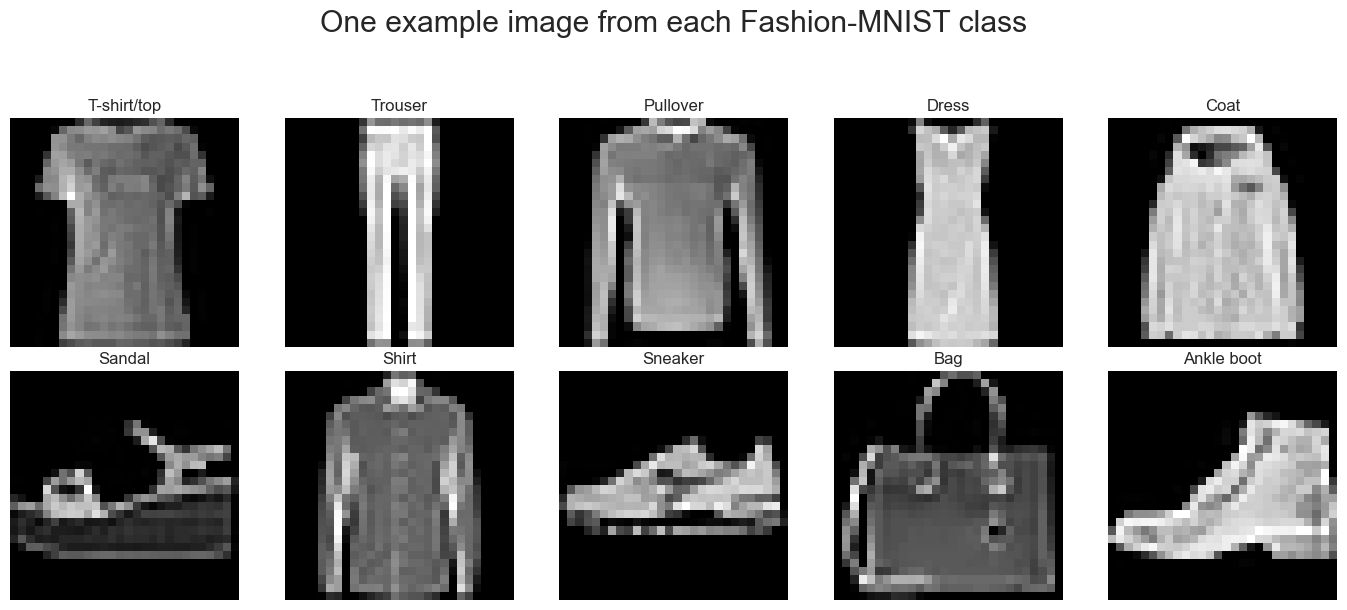

,Class,Train,Validation,Test
0,T-shirt/top,1000,200,1000
1,Trouser,1000,200,1000
2,Pullover,1000,200,1000
3,Dress,1000,200,1000
4,Coat,1000,200,1000
5,Sandal,1000,200,1000
6,Shirt,1000,200,1000
7,Sneaker,1000,200,1000
8,Bag,1000,200,1000
9,Ankle boot,1000,200,1000


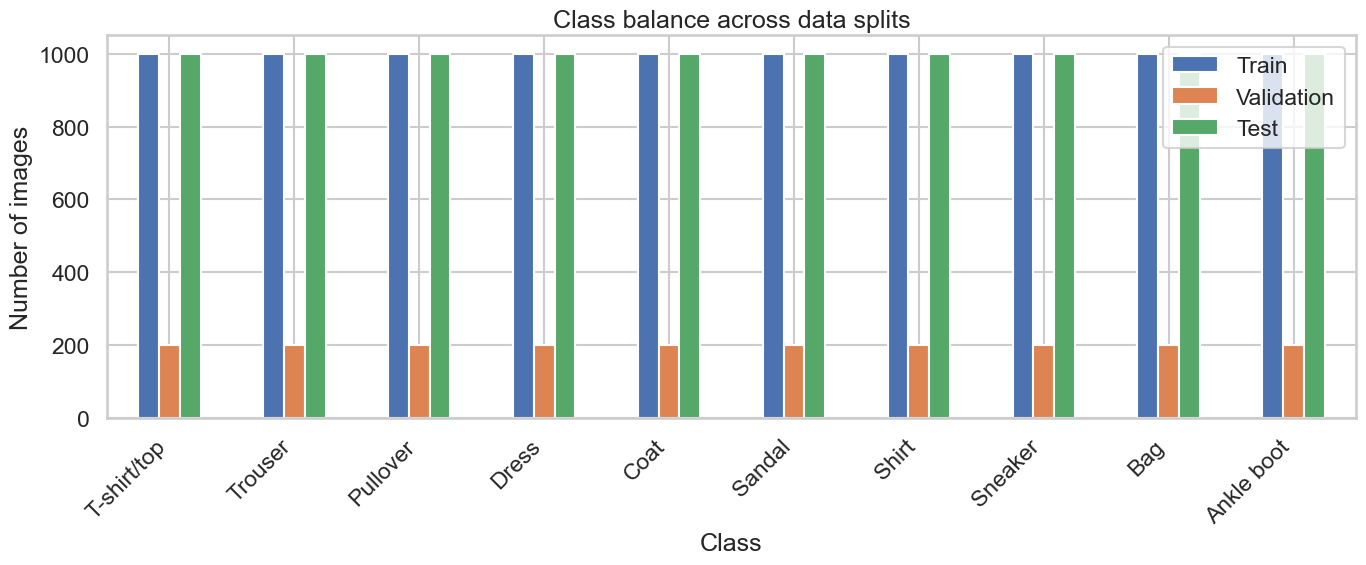

,Split,Mean pixel intensity,Std. dev.,Min,Max
0,Train,0.286235,0.353440,0.0,1.0
1,Validation,0.287667,0.354391,0.0,1.0
2,Test,0.286849,0.352444,0.0,1.0


In [ ]:
# Show one example image from each class so the reader can see what the
# prediction task looks like.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for class_id, ax in enumerate(axes.flat):
    example_idx = np.where(y_train == class_id)[0][0]
    ax.imshow(X_train[example_idx], cmap="gray")
    ax.set_title(CLASS_NAMES[class_id], fontsize=12)
    ax.axis("off")

plt.suptitle("One example image from each Fashion-MNIST class", y=1.03)
plt.tight_layout()
plt.show()

class_balance = pd.DataFrame(
    {
        "Class": CLASS_NAMES,
        "Train": np.bincount(y_train, minlength=len(CLASS_NAMES)),
        "Validation": np.bincount(y_val, minlength=len(CLASS_NAMES)),
        "Test": np.bincount(y_test, minlength=len(CLASS_NAMES)),
    }
)
display(class_balance)

ax = class_balance.set_index("Class").plot(kind="bar", figsize=(14, 6))
ax.set_ylabel("Number of images")
ax.set_title("Class balance across data splits")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Basic descriptive statistics on pixel intensities.
descriptive_stats = pd.DataFrame(
    [
        {
            "Split": "Train",
            "Mean pixel intensity": float(X_train.mean()),
            "Std. dev.": float(X_train.std()),
            "Min": float(X_train.min()),
            "Max": float(X_train.max()),
        },
        {
            "Split": "Validation",
            "Mean pixel intensity": float(X_val.mean()),
            "Std. dev.": float(X_val.std()),
            "Min": float(X_val.min()),
            "Max": float(X_val.max()),
        },
        {
            "Split": "Test",
            "Mean pixel intensity": float(X_test.mean()),
            "Std. dev.": float(X_test.std()),
            "Min": float(X_test.min()),
            "Max": float(X_test.max()),
        },
    ]
)
display(descriptive_stats)

### EDA Takeaways
- The sample is **perfectly class-balanced** (as intended) through stratified sampling, which preserved the original label distribution.
- Pixel intensities are already on a common scale because values were normalized to the interval `[0, 1]`.
- Some classes are likely to be easy to distinguish visually, like **bags**, because nothing else in the dataset looks quite like the bags.
- Other classes are might be harder to differenciate because they have overlapping silhouettes, such as **shirts**, **pullovers**, and **coats**, which would affect the models edge detection.


## 4. Analysis Plan and Data Splits

For this dataset, the goal is **multiclass classification**. Each image belongs to exactly one of ten clothing categories, so the model's job is to predict the correct class label. This is logical for this dataset as the target variable is categorical, so regression would be completely inappropriate, the labels of the data are known in advance.


### Data split strategy

Three splits will be used:
- **Training set:** used to fit model parameters.
- **Validation set:** used to compare models and tune CNN hyperparameters.
- **Test set:** used once at the end for out-of-sample evaluation.

This split is important because a model can appear to perform very well on the same data it was trained on while failing to generalize to unseen examples. Separating training, validation, and test data helps reduce the risk of overfitting, supports more reliable model selection, and provides a more honest estimate of how well the final classifier will perform on new images.

 ### Split Summary

- Training images: **10,000**
- Validation images: **2,000**
- Test images: **10,000**
- Feature dimension for classical models after flattening: **784**

The training and validation sets come from the official Fashion-MNIST training split, while the test set remains untouched until the final evaluation stage.

## 5. Model Selection and Mathematical Background

I compare several models to better answer the research question as it better shows the progression of accuracy by the more advanced architecture. The sequence moves from a trivial baseline, to simple probabilistic and linear models, and finally to a convolutional neural network that is better suited to image structure.

### Models included

1. **Majority-class baseline**  
2. **Gaussian Naive Bayes**  
3. **Logistic regression**  
4. **PCA + logistic regression**  
5. **A small CNN**

### 5.1 Majority-class baseline

This model always predicts the most common class in the training data, regardless of the input image. It does not learn any relationship between pixel values and clothing labels, so it serves only as a minimum benchmark. The purpose of such a baseline is to establish a floor for performance, so if a more advanced model cannot outperform this baseline, then the learned model is not extracting useful structure from the data.

### 5.2 Gaussian Naive Bayes

Naive Bayes predicts a class by combining a prior belief about how common each class is with evidence from each feature:

$$
p(y \mid x_1, \dots, x_d) \propto p(y) \prod_{j=1}^{d} p(x_j \mid y)
$$

Here, $y$ is the class label, and $x_1, \dots, x_d$ are the input features, where each feature corresponds to one pixel value. The term $p(y)$ is the **prior probability** of class $y$, meaning how likely that class is before looking at the image. The term $p(x_j \mid y)$ is the **likelihood** of observing pixel value $x_j$ if the image truly belongs to class $y$. The product over all $d$ features combines the evidence from every pixel.

The proportionality symbol means the right-hand side is not yet normalized into a proper probability distribution. After computing this quantity for each class, the model compares the values and chooses the class with the largest posterior probability.

What makes this Gaussian is the assumption for each feature to follow a normal distribution. So for each class, the model summarizes each pixel using a mean and variance. This is computationally simple, but it treats each pixel as conditionally independent of every other pixel once the class is known. For image data, this is clearly unrealistic, since neighboring pixels are often highly related. Still, Gaussian Naive Bayes is useful as a fast probabilistic baseline because it shows how far one can get with very simple distributional assumptions.

### 5.3 Multinomial logistic regression

Logistic regression is a discriminative linear classifier. For multiclass prediction, it estimates the probability of each class using the softmax function:

$$
p(y = k \mid x) = \frac{\exp(w_k^T x + b_k)}{\sum_{j=1}^{K} \exp(w_j^T x + b_j)}
$$

In this equation, $x$ is the input vector of pixel values, $K$ is the total number of classes, $w_k$ is the weight vector for class $k$, and $b_k$ is the bias term for class $k$. The quantity $w_k^T x + b_k$ is the **score** the model assigns to class $k$. It is a weighted sum of the input features plus an offset. Intuitively, the weights tell the model which pixels push the prediction toward or away from a given class.

The exponential function ensures that all class scores become positive. The denominator sums these exponentiated scores across all classes, which normalizes the output so the predicted probabilities add up to 1. This lets the model output a full probability distribution over the ten clothing categories.

As a whole, the softmax equation turns a set of raw linear scores into interpretable class probabilities. The model learns the weights and biases that make the correct class score highest for training examples. Compared with Naive Bayes, logistic regression is stronger because it does not assume pixel independence. However, it is still a **linear** model, so its ability to capture more complex image patterns is limited.

### 5.4 Principal component analysis (PCA)

PCA transforms the original input into a smaller set of derived features:

$$
z = W^T x
$$

Here, $x$ is the original high-dimensional input vector, $W$ is a matrix whose columns are the principal components, and $z$ is the lower-dimensional representation of the data after projection. Each column of $W$ defines a direction in feature space along which the data vary strongly. The transpose $W^T$ projects the original data onto those directions.

PCA replaces the original pixel basis with a new coordinate system that captures the most important variation in the dataset. Instead of using every raw pixel directly, the model uses a smaller number of summary dimensions that preserve as much variance as possible.

As a whole, PCA serves two purposes here. First, it reduces dimensionality, which can make downstream models faster and less noisy. Second, it can improve generalization if the discarded directions mostly contain redundancy or noise. However, PCA preserves directions of high variance, not necessarily directions that are most useful for classification. So for this assignment, PCA + logistic regression tests whether a more compact representation helps performance or whether useful class information is lost during compression.

### 5.5 Convolutional neural network (CNN)

A convolutional layer computes feature maps by applying learned filters to local regions of the image:

$$
h^{(l)}_{i,j,c} = \sigma\left((W_c * x^{(l-1)})_{i,j} + b_c\right)
$$

In this expression, $x^{(l-1)}$ is the input to layer $l$, $W_c$ is the filter for channel $c$, $*$ denotes convolution, $b_c$ is a bias term, and $\sigma$ is a nonlinear activation function such as ReLU. The output $h^{(l)}_{i,j,c}$ is the activation at spatial position $(i,j)$ in channel $c$ of layer $l$.

The convolution operation slides the filter across the image and computes how strongly that filter matches each local patch. If a filter has learned to detect something like an edge, corner, or texture, then it will produce a strong response in regions where that pattern appears. The bias term shifts the pre-activation value, and the nonlinearity allows the network to learn more complex functions than a purely linear system could represent.

As a whole, this equation shows how CNNs build structured image representations from local patterns. This is especially appropriate for the Fashion-MNIST dataset because nearby pixels to show shapes, edges, seams, and outlines, which are combined as spatial patterns. Unlike Naive Bayes or logistic regression on flattened pixels, a CNN can exploit this local structure.

### Training algorithm in pseudocode

```text
for each epoch:
    for each minibatch:
        compute model outputs
        compute loss
        backpropagate gradients
        update parameters with Adam
    evaluate on validation set
    keep the checkpoint with the best validation macro F1

In [7]:
def evaluate_predictions(y_true, y_pred):
    """Return the two summary metrics used throughout the notebook."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


# Classical baseline models. The pipelines ensure that scaling and PCA
# are learned only from training data, which prevents data leakage.
classical_models = {
    "Majority class": DummyClassifier(strategy="most_frequent"),
    "Gaussian Naive Bayes": GaussianNB(),
    "Logistic regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    max_iter=300,
                    solver="lbfgs",
                    C=2.0,
                    random_state=SEED,
                ),
            ),
        ]
    ),
    "PCA + Logistic regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=100, svd_solver="randomized", random_state=SEED)),
            (
                "classifier",
                LogisticRegression(
                    max_iter=300,
                    solver="lbfgs",
                    C=2.0,
                    random_state=SEED,
                ),
            ),
        ]
    ),
}


class FashionCNN(nn.Module):
    """Small LeNet-style CNN used for the deep-learning comparison."""

    def __init__(self, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, len(CLASS_NAMES)),
        )

    def forward(self, inputs):
        features = self.features(inputs)
        return self.classifier(features)


cnn_search_space = [
    {
        "name": "CNN-small",
        "hidden_dim": 256,
        "dropout": 0.30,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "CNN-large",
        "hidden_dim": 384,
        "dropout": 0.40,
        "lr": 8e-4,
        "weight_decay": 1e-4,
    },
]

## 6. Model Training, Cross Validation, and Hyperparameter Tuning

This section fits the models and compares them on the validation set.

### Training strategy

- The classical models are fit once on the training split and evaluated on validation and test data.
- The CNN is trained with mini-batch gradient descent using **Adam**.
- The CNN search compares two small architectures that differ in hidden-layer width and dropout.
- The best CNN checkpoint is selected by **validation macro F1** rather than training loss.

### Why macro F1?

The **F1 score** combines **precision** and **recall** into a single, comparable, number. Precision measures, out of the examples predicted as a class, how many were actually correct. Recall measures, out of the examples that truly belong to a class, how many the model successfully found. The F1 score is the harmonic mean of precision and recall given by:

$$
F1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$

A model can only get a high F1 score when it performs well on **both** precision and recall. If one is low, the F1 score will also be low.

In a multiclass setting, there is one F1 score for each class. **Macro F1** computes the F1 score separately for each class and then takes the simple average across classes. Every class contributes equally to the final score, regardless of how frequent that class is in the dataset.

Macro F1 is a useful comparison metric for the task at hand because plain accuracy can be misleading. A model can achieve high accuracy by doing very well on easier or more common classes while still performing poorly on harder classes. Since this project compares performance across ten clothing categories, the evaluation should not be dominated by the classes the model finds easiest. Using macro F1 makes the selection criterion more sensitive to balanced performance across all categories. Thus, a **validation macro F1** is used to choose the best CNN checkpoint because it better reflects whether the model is learning to classify the full set of clothing categories well, rather than simply minimizing loss or maximizing overall accuracy.

In [8]:
# Fit the classical models and store their predictions so they can be
# compared with the CNN later.
classical_results = []
classical_predictions = {}

for model_name, model in classical_models.items():
    start = time.time()
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        model.fit(X_train_flat, y_train)
    elapsed = time.time() - start

    val_pred = model.predict(X_val_flat)
    test_pred = model.predict(X_test_flat)

    val_scores = evaluate_predictions(y_val, val_pred)
    test_scores = evaluate_predictions(y_test, test_pred)

    classical_results.append(
        {
            "model": model_name,
            "validation_accuracy": val_scores["accuracy"],
            "validation_macro_f1": val_scores["macro_f1"],
            "test_accuracy": test_scores["accuracy"],
            "test_macro_f1": test_scores["macro_f1"],
            "fit_seconds": elapsed,
        }
    )

    classical_predictions[model_name] = {
        "validation": val_pred,
        "test": test_pred,
    }

classical_results_df = pd.DataFrame(classical_results).sort_values(
    by=["validation_macro_f1", "test_macro_f1"],
    ascending=False,
)
display(
    classical_results_df.style.format(
        {
            "validation_accuracy": "{:.3f}",
            "validation_macro_f1": "{:.3f}",
            "test_accuracy": "{:.3f}",
            "test_macro_f1": "{:.3f}",
            "fit_seconds": "{:.1f}",
        }
    )
)

best_classical_name = classical_results_df.iloc[0]["model"]
print(f"Best classical model by validation macro F1: {best_classical_name}")

,model,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,fit_seconds
3,PCA + Logistic regression,0.845,0.844,0.826,0.824,12.5
2,Logistic regression,0.793,0.793,0.798,0.798,22.7
1,Gaussian Naive Bayes,0.564,0.530,0.549,0.517,0.1
0,Majority class,0.100,0.018,0.100,0.018,0.0


Best classical model by validation macro F1: PCA + Logistic regression


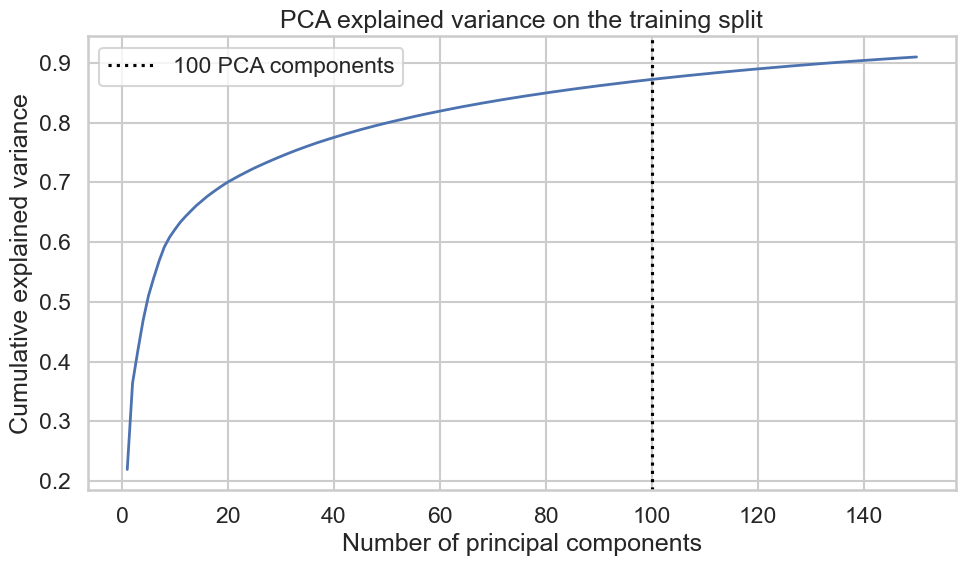

Using 100 PCA components retains approximately 0.873 of the training variance.


In [ ]:
scaler_for_diagnostics = StandardScaler()
X_train_scaled = scaler_for_diagnostics.fit_transform(X_train_flat)

pca_diagnostics = PCA(n_components=150, svd_solver="randomized", random_state=SEED)
pca_diagnostics.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_diagnostics.explained_variance_ratio_)
diagnostic_components = len(cumulative_variance)
model_components = 100
retained_variance = cumulative_variance[model_components - 1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(1, diagnostic_components + 1), cumulative_variance, linewidth=2)
ax.axvline(model_components, color="black", linestyle=":", label="100 PCA components")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA explained variance on the training split")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Using 100 PCA components retains approximately {retained_variance:.3f} of the training variance.")

The PCA explained-variance graph shows that a relatively small number of principal components captures most of the meaningful variation in the Fashion-MNIST images. In this notebook, using 100 components retains about 87.3% of the variance in the training data, which suggests that the original 784 pixel features contain substantial redundancy. This means the images can be compressed into a lower-dimensional representation without losing too much information, helping the logistic regression model train faster while still preserving strong predictive performance.

## CNN

,model,hidden_dim,dropout,lr,weight_decay,best_epoch,validation_accuracy,validation_macro_f1,fit_seconds
0,CNN-small,256,0.30,0.0010,0.0001,7,0.892,0.892,27.0
1,CNN-large,384,0.40,0.0008,0.0001,4,0.884,0.885,16.0


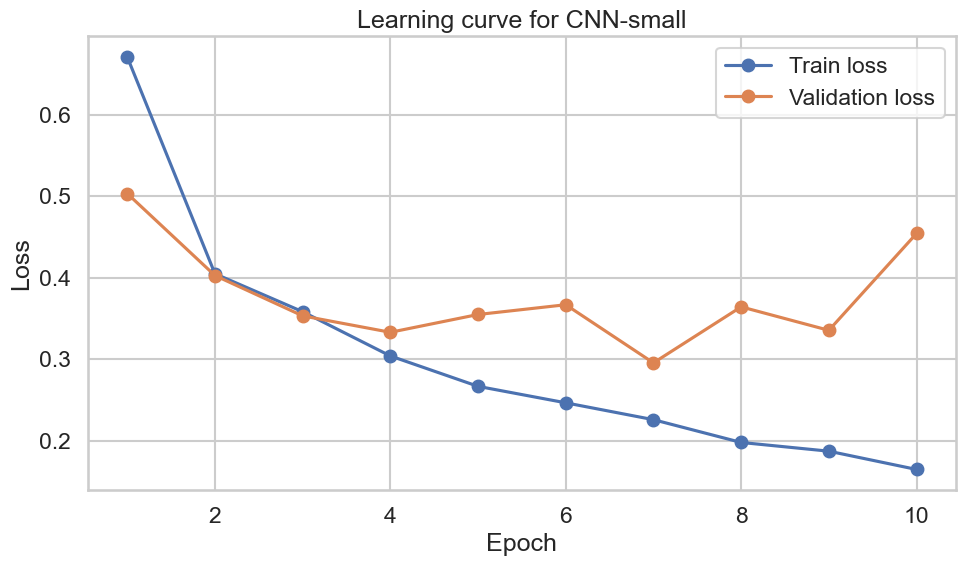

In [ ]:
# Convert the NumPy arrays into tensors and DataLoaders for PyTorch.
X_train_tensor = torch.tensor(X_train[:, None, :, :], dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val[:, None, :, :], dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test[:, None, :, :], dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


def evaluate_torch_model(model, data_loader):
    """Evaluates a CNN on a loader and returns the loss plus classification metrics."""
    model.eval()
    all_preds = []
    all_targets = []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch_inputs, batch_targets in data_loader:
            batch_inputs = batch_inputs.to(DEVICE)
            batch_targets = batch_targets.to(DEVICE)
            logits = model(batch_inputs)
            loss = criterion(logits, batch_targets)
            total_loss += loss.item() * batch_inputs.size(0)

            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(batch_targets.cpu().numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    return {
        "loss": total_loss / len(data_loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def train_cnn(config, epochs=EPOCHS, patience=PATIENCE):
    """Trains a CNN configuration and keep the best validation checkpoint."""
    model = FashionCNN(hidden_dim=config["hidden_dim"], dropout=config["dropout"]).to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    criterion = nn.CrossEntropyLoss()

    history = []
    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf
    best_epoch = 0
    wait = 0
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for batch_inputs, batch_targets in train_loader:
            batch_inputs = batch_inputs.to(DEVICE)
            batch_targets = batch_targets.to(DEVICE)

            optimizer.zero_grad()
            logits = model(batch_inputs)
            loss = criterion(logits, batch_targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch_inputs.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_metrics = evaluate_torch_model(model, val_loader)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
            }
        )

        if val_metrics["macro_f1"] > best_val_f1 + 1e-4:
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    elapsed = time.time() - start_time
    history_df = pd.DataFrame(history)
    return model, history_df, elapsed, best_epoch


cnn_search_results = []
cnn_histories = {}
trained_cnn_models = {}

for config in cnn_search_space:
    model, history_df, elapsed, best_epoch = train_cnn(config)
    val_metrics = evaluate_torch_model(model, val_loader)

    cnn_search_results.append(
        {
            "model": config["name"],
            "hidden_dim": config["hidden_dim"],
            "dropout": config["dropout"],
            "lr": config["lr"],
            "weight_decay": config["weight_decay"],
            "best_epoch": best_epoch,
            "validation_accuracy": val_metrics["accuracy"],
            "validation_macro_f1": val_metrics["macro_f1"],
            "fit_seconds": elapsed,
        }
    )
    cnn_histories[config["name"]] = history_df
    trained_cnn_models[config["name"]] = model

cnn_search_df = pd.DataFrame(cnn_search_results).sort_values(
    by="validation_macro_f1",
    ascending=False,
)
display(
    cnn_search_df.style.format(
        {
            "dropout": "{:.2f}",
            "lr": "{:.4f}",
            "weight_decay": "{:.4f}",
            "validation_accuracy": "{:.3f}",
            "validation_macro_f1": "{:.3f}",
            "fit_seconds": "{:.1f}",
        }
    )
)

best_cnn_name = cnn_search_df.iloc[0]["model"]
best_cnn_model = trained_cnn_models[best_cnn_name]
best_cnn_history = cnn_histories[best_cnn_name]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(best_cnn_history["epoch"], best_cnn_history["train_loss"], marker="o", label="Train loss")
ax.plot(best_cnn_history["epoch"], best_cnn_history["val_loss"], marker="o", label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Learning curve for {best_cnn_name}")
ax.legend()
plt.tight_layout()
plt.show()

The CNN comparison shows that both architectures performed well, but the smaller CNN was the better model overall. CNN-small achieved a higher validation macro F1 than CNN-large, suggesting that increasing model size did not improve generalization. Similarly, the learning-curve graph shows that training loss decreases steadily while validation loss stabilizes, indicating that the model is learning useful structure without substantial additional gains from a larger architecture. This suggests a modest CNN is expressive enough to capture the important local image patterns in the Fashion-MNIST datset, while a larger architecture adds complexity without improving validation performance.

The test set is intentionally not used at this stage. Model selection is based only on validation results so that the final test evaluation remains a fair estimate of how well the chosen model generalizes to unseen data.

## 7. Out-of-Sample Predictions and Performance Metrics

The models are now applied to the **held-out test set** to measure how well the models generalize to images they were never trained on.

### Metrics used
- **Accuracy:** the fraction of all predictions that are correct.
- **Macro F1:** the average F1 score across classes, giving each class equal weight.

Macro F1 is especially useful here because some classes are harder than others, and a model that does well only on easy classes would be misleading.

In [12]:
cnn_val_metrics = evaluate_torch_model(best_cnn_model, val_loader)
cnn_test_metrics = evaluate_torch_model(best_cnn_model, test_loader)

cnn_result = pd.DataFrame(
    [
        {
            "model": best_cnn_name,
            "validation_accuracy": cnn_val_metrics["accuracy"],
            "validation_macro_f1": cnn_val_metrics["macro_f1"],
            "test_accuracy": cnn_test_metrics["accuracy"],
            "test_macro_f1": cnn_test_metrics["macro_f1"],
            "fit_seconds": cnn_search_df.iloc[0]["fit_seconds"],
        }
    ]
)

comparison_df = (
    pd.concat([classical_results_df, cnn_result], ignore_index=True)
    .sort_values(by="test_macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(
    comparison_df.style.format(
        {
            "validation_accuracy": "{:.3f}",
            "validation_macro_f1": "{:.3f}",
            "test_accuracy": "{:.3f}",
            "test_macro_f1": "{:.3f}",
            "fit_seconds": "{:.1f}",
        }
    )
)

,model,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,fit_seconds
0,CNN-small,0.892,0.892,0.889,0.890,27.0
1,PCA + Logistic regression,0.845,0.844,0.826,0.824,12.5
2,Logistic regression,0.793,0.793,0.798,0.798,22.7
3,Gaussian Naive Bayes,0.564,0.530,0.549,0.517,0.1
4,Majority class,0.100,0.018,0.100,0.018,0.0


## 8. Visualizing the Results and Discussing Conclusions

Although the summary metric table provides an important overview of model performance, it does not fully explain **how** the models are making mistakes. For that reason, the visualizations below are used to examine the results in more detail. In particular, they help reveal which class pairs are most often confused, whether the CNN corrects errors that the classical models tend to make, and whether the remaining mistakes are sensible given the visual similarity of certain clothing categories.

These questions matter because strong machine-learning analysis is not only about reporting a final score. It is also about interpreting the structure of the errors, understanding what the model has actually learned, and identifying the limits of its performance. Looking at confusion patterns therefore gives a more complete picture of model quality than accuracy or macro F1 alone.

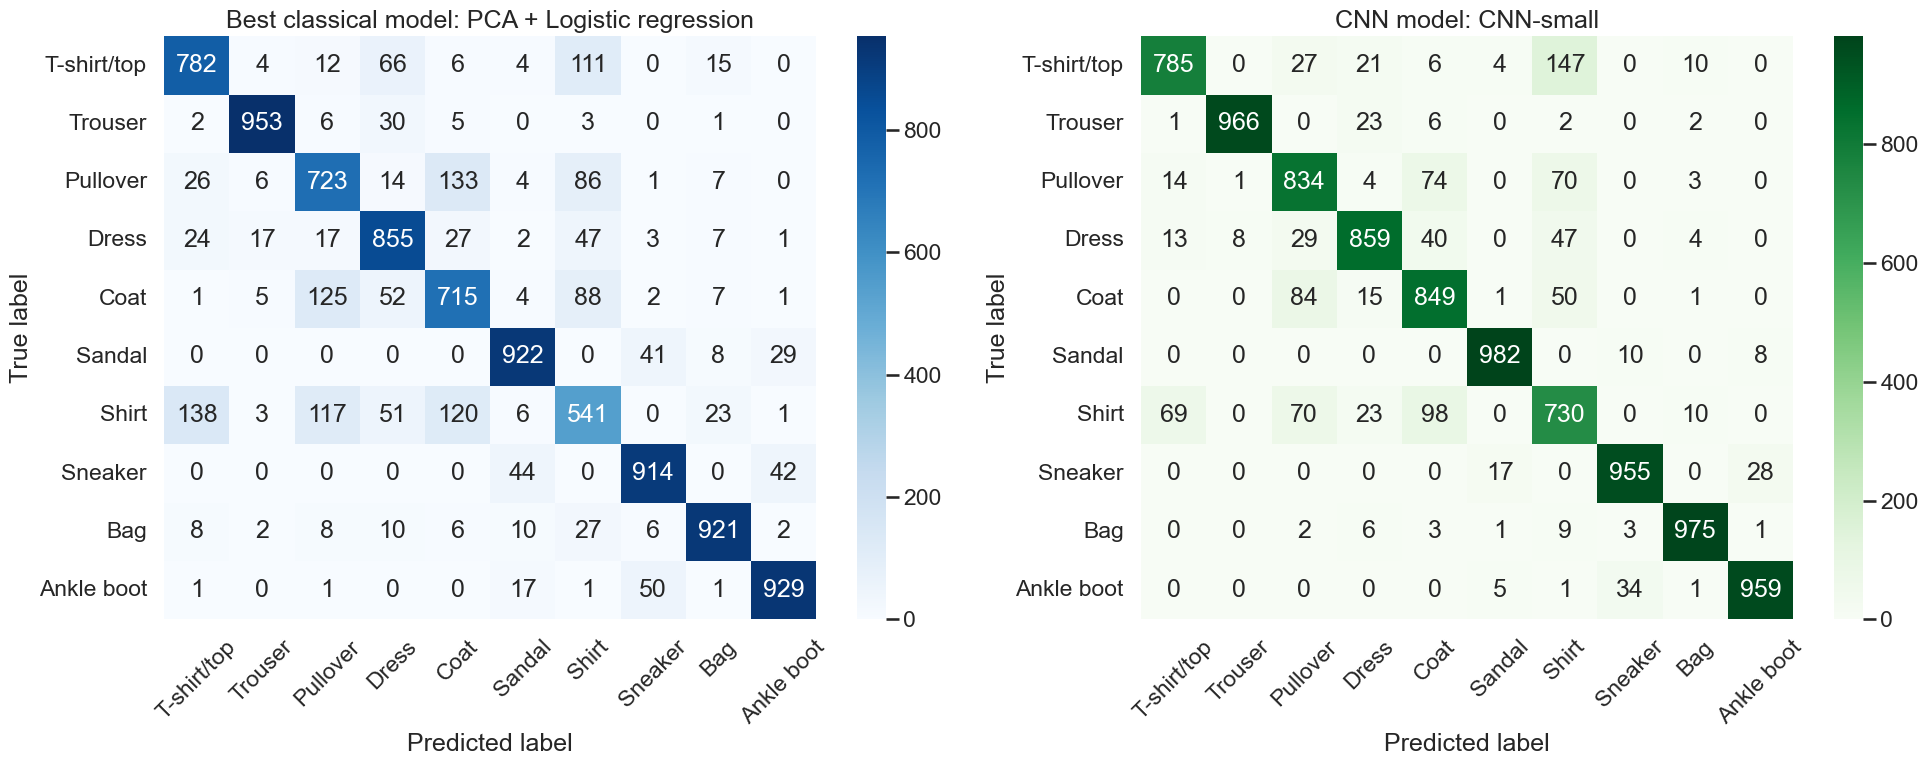

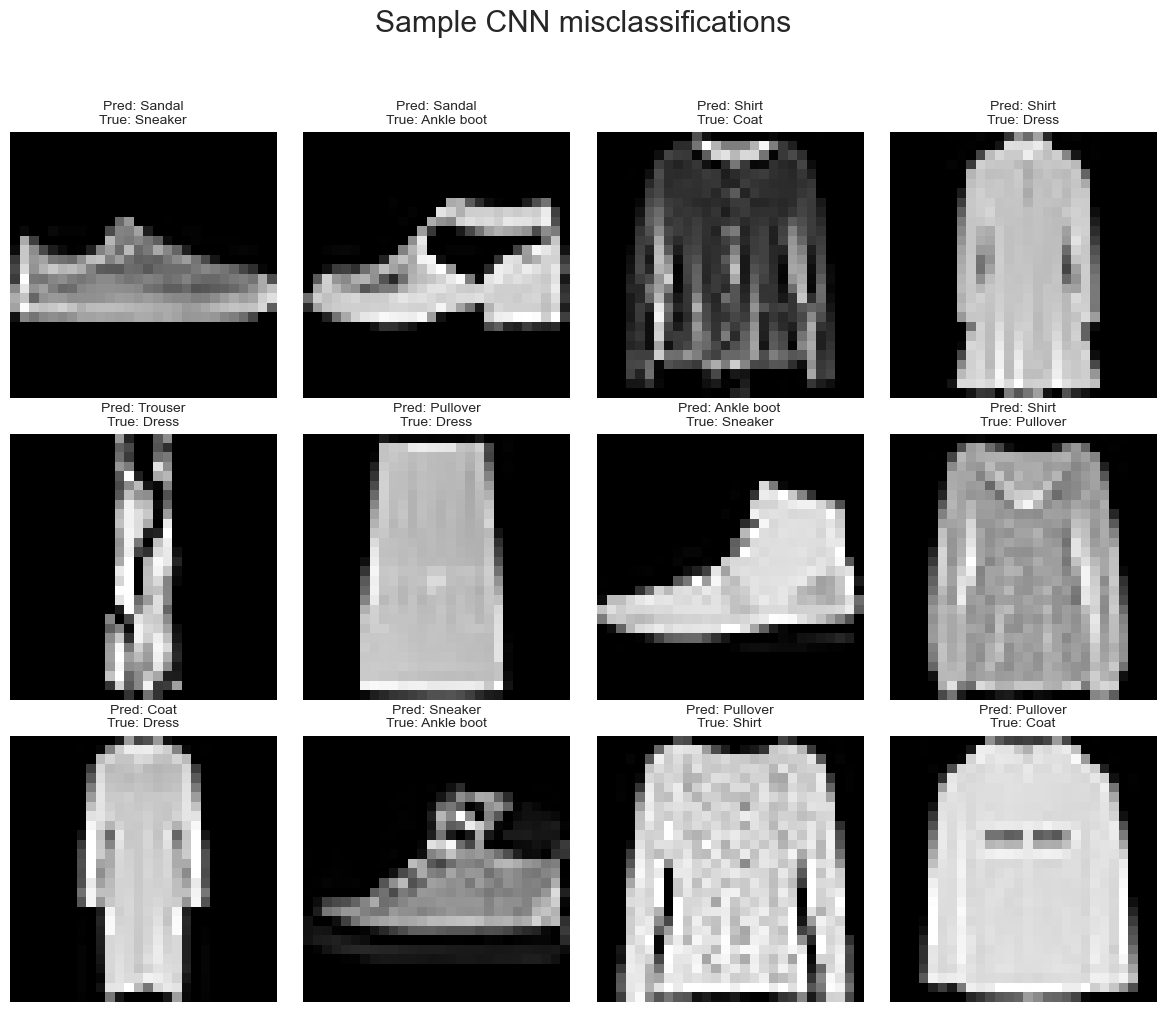

In [13]:
best_classical_pred = classical_predictions[best_classical_name]["test"]
cm_classical = confusion_matrix(y_test, best_classical_pred)
cm_cnn = confusion_matrix(cnn_test_metrics["y_true"], cnn_test_metrics["y_pred"])

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    cm_classical,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0],
)
axes[0].set_title(f"Best classical model: {best_classical_name}")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1],
)
axes[1].set_title(f"CNN model: {best_cnn_name}")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

misclassified = np.where(cnn_test_metrics["y_true"] != cnn_test_metrics["y_pred"])[0][:12]
fig, axes = plt.subplots(3, 4, figsize=(12, 10))

for ax, idx in zip(axes.flat, misclassified):
    ax.imshow(X_test[idx], cmap="gray")
    ax.set_title(
        f"Pred: {CLASS_NAMES[cnn_test_metrics['y_pred'][idx]]}\nTrue: {CLASS_NAMES[cnn_test_metrics['y_true'][idx]]}",
        fontsize=10,
    )
    ax.axis("off")

for ax in axes.flat[len(misclassified):]:
    ax.axis("off")

plt.suptitle("Sample CNN misclassifications", y=1.02)
plt.tight_layout()
plt.show()

### Results Discussion

The results show a clear performance hierarchy across the models. Among the classical approaches, **PCA + Logistic Regression** performed best, achieving a test macro F1 of **0.824**. This suggests that reducing the dimensionality of the raw pixel space before classification helped the linear model focus on the most informative variation in the images. However, the strongest overall model was **CNN-small**, which achieved a test macro F1 of **0.890**. This outperformed the best classical baseline by **0.066**, indicating that the CNN was better able to capture the local spatial patterns that matter for image recognition.

The improvement over the **majority-class baseline** is even larger: **0.872** in macro F1. This confirms that the final model is learning substantial structure from the data rather than relying on class frequency alone. More broadly, the results support the expectation that architectures designed for images should outperform models that treat the input as a flat vector of independent features.

The error plots suggest that the remaining mistakes are concentrated among visually similar upper-body garments, especially **shirts**, **pullovers**, and **coats**. This pattern is intuitive, since these categories often share overlapping shapes, silhouettes, and textures in low-resolution grayscale images. That makes the remaining errors meaningful rather than random, and it supports the interpretation that the CNN is learning genuine visual structure in the dataset rather than memorizing arbitrary patterns.

### Confusion Matrix Interpretation
The confusion matrices show that the hardest part of this task is not telling very different items apart, but distinguishing between **visually similar clothing categories**. The most common errors are concentrated among upper-body garments such as **T-shirt/top, shirt, pullover, and coat**. This is especially clear in the classical model, where categories like **shirt → T-shirt/top**, **pullover → coat**, and **coat → pullover** are confused frequently. The CNN improves performance overall, but its remaining mistakes are still concentrated in these same categories, which suggests that these classes are genuinely difficult to separate.

This pattern makes intuitive sense. In **28 × 28 grayscale images**, many of the details that distinguish these garments — such as sleeve shape, collar structure, or fabric thickness are hard to see clearly, even to the naked eye. By contrast, classes with more distinctive shapes, such as **trousers, bags, sandals, and ankle boots**, are classified much more reliably. The main shoe-related confusion that remains is **sneaker vs ankle boot**, rather than a broad failure across all shoe categories.

The misclassified-image grid helps explain these results visually. Instead of showing just counts, it displays individual test examples the CNN got wrong, making it possible to judge whether the errors are understandable. In many cases, they are: several of the incorrect predictions look genuinely ambiguous at this resolution. Together, these visualizations suggest that the CNN is learning meaningful image structure, but that its remaining errors are concentrated in fine-grained categories with overlapping silhouettes rather than being random mistakes.

## 9. Executive Summary

This assignment compares several approaches to multiclass image classification on **Fashion-MNIST** in order to answer a focused question: how much does a simple convolutional neural network improve performance relative to classical machine-learning baselines? To make that comparison fair, the same underlying dataset was prepared in two representations: **flattened 784-dimensional vectors** for the classical models and **28 × 28 image tensors** for the CNN. The modeling pipeline included a majority-class baseline, Gaussian Naive Bayes, logistic regression, PCA + logistic regression, and two small CNN configurations selected using a validation split before final evaluation on the held-out test set.

The best overall model was **CNN-small**, which achieved a **test macro F1 of 0.890**, while the strongest classical baseline, **PCA + Logistic Regression**, achieved **0.824**. This gap suggests that preserving local spatial structure matters for image classification: once the model can learn edges, shapes, and nearby pixel relationships directly, it performs better than methods that treat the image as a flat vector. The confusion matrices support this interpretation. Most remaining errors are concentrated among visually similar upper-body garments such as **T-shirt/top, shirt, pullover, and coat**, which are genuinely difficult to distinguish in low-resolution grayscale images. 

The biggest limitation of this project is that **Fashion-MNIST is a highly standardized benchmark** rather than messy real-world image data. The images are centered, uniformly sized, grayscale, cleanly labeled, and class-balanced, and the train and test sets come from the same distribution. Real personal-archive data would be much harder, as images may vary in lighting, angle, background, cropping, color, occlusion, image quality, and class frequency, and labels may be noisier as well. That means these results should be interpreted as strong evidence about model behavior on a clean benchmark, not as proof that the same performance gap would carry over unchanged to a real archive.

There are also several secondary limitations. First, the notebook uses a **reduced working subset** of the official training data (**10,000** training images and **2,000** validation images) rather than the full 60,000-image training set, so the final scores may understate what some models could achieve with more data. Second, the CNN search is intentionally modest: only **two small architectures** are compared, with limited hyperparameter exploration, no data augmentation, and no transfer learning. Third, the classical models are mainly included as baselines rather than being exhaustively optimized. Together, these choices make the notebook computationally manageable and analytically clear, but they also mean the project prioritizes **clean comparison** over exhaustive performance maximization.

Overall, the notebook succeeds in showing a meaningful and interpretable pattern: on a visual classification task, models that preserve image structure outperform models that flatten it away. At the same time, the project’s strongest future improvement is obvious: repeat this pipeline on a **less standardized, more personally relevant image dataset**. That would make the work more original and would provide a much better test of whether the same modeling conclusions hold once the data begin to look like the real world.

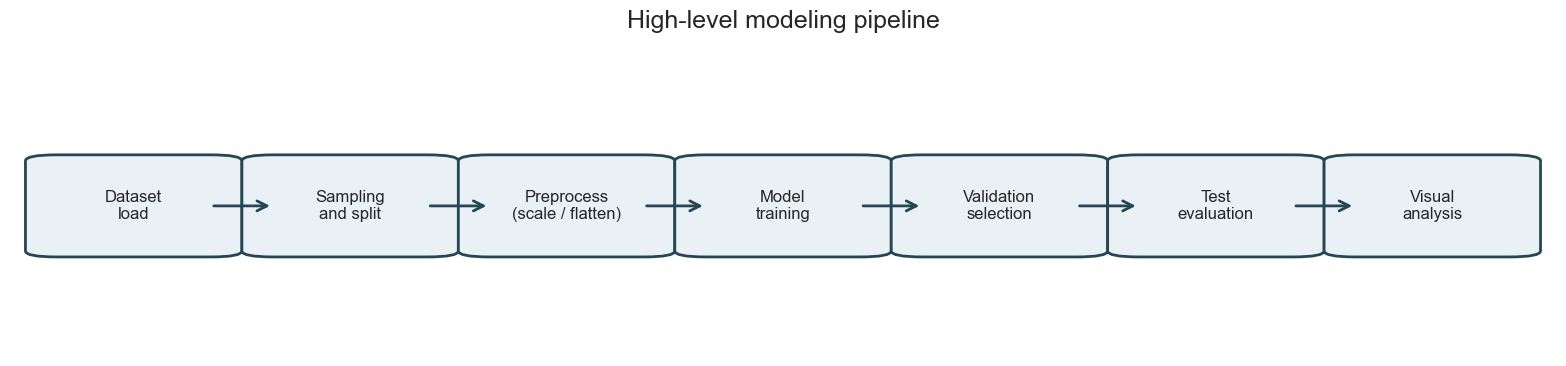

,model,test_accuracy,test_macro_f1
0,CNN-small,0.889,0.890
1,PCA + Logistic regression,0.826,0.824
2,Logistic regression,0.798,0.798
3,Gaussian Naive Bayes,0.549,0.517
4,Majority class,0.100,0.018


In [16]:
# Draw a compact pipeline diagram for the executive summary.
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis("off")

steps = [
    "Dataset\nload",
    "Sampling\nand split",
    "Preprocess\n(scale / flatten)",
    "Model\ntraining",
    "Validation\nselection",
    "Test\nevaluation",
    "Visual\nanalysis",
]
x_positions = np.linspace(0.03, 0.87, len(steps))

for i, (x, label) in enumerate(zip(x_positions, steps)):
    box = FancyBboxPatch(
        (x, 0.35),
        0.1,
        0.3,
        boxstyle="round,pad=0.02",
        linewidth=2,
        edgecolor="#264653",
        facecolor="#E9F1F7",
    )
    ax.add_patch(box)
    ax.text(x + 0.05, 0.5, label, ha="center", va="center", fontsize=12)
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i + 1], 0.5),
            xytext=(x + 0.1, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2, color="#264653"),
        )

plt.title("High-level modeling pipeline", pad=20)
plt.tight_layout()
plt.show()

top_results = comparison_df[["model", "test_accuracy", "test_macro_f1"]].copy()
display(top_results.style.format({"test_accuracy": "{:.3f}", "test_macro_f1": "{:.3f}"}))

best_model_name = comparison_df.iloc[0]["model"]
best_model_f1 = comparison_df.iloc[0]["test_macro_f1"]
second_model_name = comparison_df.iloc[1]["model"]
second_model_f1 = comparison_df.iloc[1]["test_macro_f1"]

## Takeaway

The final ranking shows that **CNN-small** performed best on held-out data, achieving a test macro F1 of **0.890**. The runner-up was **PCA + Logistic Regression**, with a test macro F1 of **0.824**. This gap suggests that the strongest gains came from using a model architecture that preserves local spatial structure rather than treating the image as a flat vector of pixels as the model benefits from being able to learn patterns such as edges, shapes, and local textures directly from the image layout.

Classical models such as logistic regression and Gaussian Naive Bayes were provided useful baselines, and PCA helped improve the strongest classical approach by reducing redundancy in the pixel space. However, the CNN ultimately performed best because it was better matched to the underlying problem. Its stronger macro F1 suggests not only higher overall performance, but also more balanced classification across the ten clothing categories.

There are several clear directions for improvement. A stronger next step would be to replace Fashion-MNIST with a labeled sample drawn from a real personal image archive, since that would make the project more original and better test how well these methods transfer to a less standardized setting. The CNN search could also be expanded more systematically by exploring a wider range of hyperparameters and architectures rather than comparing only a small number of candidate models. If the archive dataset is relatively small, data augmentation would likely help by increasing variation in the training images and reducing overfitting. Finally, if the image collection is more visually complex than Fashion-MNIST, transfer learning would be a promising extension, since pretrained models can capture richer visual features than a small CNN trained from scratch.

## 10. References

- Xiao, Han, Kashif Rasul, and Roland Vollgraf. 2017. *Fashion-MNIST: A Novel Image Dataset for Benchmarking Machine Learning Algorithms*. arXiv:1708.07747.
- LeCun, Yann, Leon Bottou, Yoshua Bengio, and Patrick Haffner. 1998. *Gradient-Based Learning Applied to Document Recognition*. *Proceedings of the IEEE* 86(11): 2278-2324.
- [PyTorch Tutorials](https://pytorch.org/tutorials/). Used for implementation guidance on dataset loading and neural-network training loops.
- [scikit-learn PCA documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). Used for the dimensionality-reduction discussion and implementation.
- [scikit-learn LogisticRegression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Used for the linear baseline setup.
- [scikit-learn DummyClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html). Used for the majority-class baseline.
- [scikit-learn GaussianNB documentation](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html). Used for the Naive Bayes baseline.